In [2]:
# ==========================================
# Cell 1: Imports and Directory Setup
# ==========================================
import os
import glob
import pickle
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy.table import Table
from tqdm import tqdm

import slsim.Sources as sources
from utils import extract_lens_properties, make_multiband_images_and_rgb_image

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# Define and create output directories
img_dir = "../data/lenses/images/"
table_dir = "../data/lenses/"
os.makedirs(img_dir, exist_ok=True)
os.makedirs(table_dir, exist_ok=True)

In [3]:
# ==========================================
# Cell 2: Setup Field Galaxy Population
# ==========================================
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
sky_area_galaxy = Quantity(50, "deg2")

print("Loading SkyPy catalog for field galaxies...")
all_galaxy_catalog = Table.read(f'../catalogs/skypy_all_galaxies_{sky_area_galaxy.value}deg2.fits', format='fits')

field_galaxy_pop = sources.Galaxies(
    galaxy_list=all_galaxy_catalog, 
    kwargs_cut={"band": "i", "band_max": 26, "z_min": 0.01, "z_max": 5.0}, 
    cosmo=cosmo, 
    sky_area=sky_area_galaxy, 
    catalog_type="skypy"
)

Loading SkyPy catalog for field galaxies...


In [4]:
# ==========================================
# Cell 3: Load Lenses and Inject Field Galaxies
# ==========================================
lensed_quasars_all = []
lens_files = glob.glob("../saved_objects/lensed_quasars_balanced_*.pkl")

print(f"Found {len(lens_files)} lens files. Loading...")
for file in lens_files:
    with open(file, "rb") as f:
        lensed_quasars_all.extend(pickle.load(f))
        
print(f"Total lenses loaded: {len(lensed_quasars_all)}")

Found 1 lens files. Loading...
Total lenses loaded: 50000


In [5]:
test_table = extract_lens_properties(lensed_quasars_all[:100], all_bands=['g', 'r', 'i', 'z', 'y'], max_num_images=5)

Extracting lens properties: 100%|██████████| 100/100 [00:11<00:00,  8.55it/s]


In [6]:
test_table

Lens ID,RA,Dec,num_images,zlens,vel_disp,ell_m,ell_m_PA,sh,sh_PA,Rein,ell_l,ell_l_PA,Reff_l,n_l_sers,zsrc,srcx,srcy,ell_s,ell_s_PA,Reff_s,n_s_sers,psx,psy,bh_mass_exp,edd_ratio,dt_max,mag_lens_g,mag_src_g,mag_ps_g,mag_lens_r,mag_src_r,mag_ps_r,mag_lens_i,mag_src_i,mag_ps_i,mag_lens_z,mag_src_z,mag_ps_z,mag_lens_y,mag_src_y,mag_ps_y,dt_days_1,mu_1,x_img_1,y_img_1,mag_ps_img_g_1,mag_ps_img_r_1,mag_ps_img_i_1,mag_ps_img_z_1,mag_ps_img_y_1,dt_days_2,mu_2,x_img_2,y_img_2,mag_ps_img_g_2,mag_ps_img_r_2,mag_ps_img_i_2,mag_ps_img_z_2,mag_ps_img_y_2,dt_days_3,mu_3,x_img_3,y_img_3,mag_ps_img_g_3,mag_ps_img_r_3,mag_ps_img_i_3,mag_ps_img_z_3,mag_ps_img_y_3,dt_days_4,mu_4,x_img_4,y_img_4,mag_ps_img_g_4,mag_ps_img_r_4,mag_ps_img_i_4,mag_ps_img_z_4,mag_ps_img_y_4,dt_days_5,mu_5,x_img_5,y_img_5,mag_ps_img_g_5,mag_ps_img_r_5,mag_ps_img_i_5,mag_ps_img_z_5,mag_ps_img_y_5
str12,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[2],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
D1_L00000000,111.76134452076958,-20.9123414513625,2,1.2226554941227958,315.3309262709185,0.051637100447009344,-4.696717734554879,0.0,90.0,1.4064619580631255,0.06921138470105208,20.181252129945836,0.6972845432128512,4.0,4.481051445007324,0.16407775244321318,-0.3130096435138695,0.07349318688867922,-2.3407934387837397e-16,0.3051459691044859,1.0 .. 2.0,0.16407775244321318,-0.3130096435138695,6.804233585647123,3.253974981956367,222.24685779108106,25.061691413880766,30.01467199584674,27.627856251338702,23.88345457075701,25.55295663357722,25.52394204300292,22.603631911638345,24.402090848157652,24.823420544408496,21.832441420969104,24.238643706260333,24.459515822561418,21.06026569320811,24.123846176745253,24.45555829488932,-390.3153299031421,4.943610891178403,0.8941568432041884,-1.455448715970719,25.89274555045738,23.788831342121597,23.088309843527174,22.724405121680096,22.720447594008,-168.06847211206107,-2.0622026906085438,-0.3914894047617474,1.0189507851326665,26.842027878447837,24.738113670112053,24.03759217151763,23.673687449670552,23.669729921998456,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
D1_L00000001,128.2838657910982,4.9241644999116545,2,0.9904031051607957,219.8905455477936,0.134903760666286,-4.476706739495869,0.0,-0.0,0.5778927939156714,0.056996918844950714,-10.015211105067678,0.4964431261186503,4.0,2.313427686691284,0.20014989559676627,-0.22399034182152844,0.001983040993984035,-1.284002982254111e-14,0.24999151350801138,1.0 .. 2.0,0.20014989559676627,-0.22399034182152844,7.967190979566842,0.6386395091008233,63.510166350772565,25.367356806819476,25.588889760388742,26.031288901798376,23.587949014976655,24.679193870401193,25.10273730804571,22.54346118322547,24.169699151955438,24.33512153812195,21.592071426147154,23.772631472173074,23.712515629326838,21.13747932619574,23.41376509305212,23.303616095792236,-79.14375173628913,2.8262090159313624,0.6587310712506258,-0.5338198791803551,24.903278208026876,23.97472661427421,23.20711084435045,22.584504935555337,22.175605402020736,-15.633585385516568,-0.9758299202264956,-0.14768030563496493,0.26985055501706934,26.057853576749917,25.12930198299725,24.36168621307349,23.739080304278378,23.330180770743777,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
D1_L00000002,127.62058485730704,-37.67212599279853,2,0.763936941119878,243.9369403762423

In [ ]:
# ==========================================
# Cell 4: Extract Properties and Save Table
# ==========================================
print("Extracting physical properties into catalog table...")
table_lensed_quasars = extract_lens_properties(lensed_quasars_all, all_bands=['g', 'r', 'i', 'z', 'y'], max_num_images=5)

table_path = os.path.join(table_dir, "table_lensed_quasars_balanced.fits")
table_lensed_quasars.write(table_path, format="fits", overwrite=True)
print(f"Saved catalog to {table_path}")

Extracting physical properties into catalog table...


Extracting lens properties: 100%|██████████| 50000/50000 [1:09:05<00:00, 12.06it/s]


Saved catalog to ../data/lenses/table_lensed_quasars_balanced.fits


In [8]:
print("Injecting field galaxies into lens cutouts...")
for lens in lensed_quasars_all:
    lens.add_field_galaxies(field_galaxies=field_galaxy_pop.draw_galaxies(area=Quantity(100, "arcsec2")))

# 100 arcsec^2 is chosen such that Area of circle enclosing the cutout of 8"x8" is fully covered, while also adding some galaxies in the outskirts to make it more realistic
# => pi*(4*sqrt(2) arcsec)^2 ~ 100 arcsec^2

Injecting field galaxies into lens cutouts...


In [12]:
# ==========================================
# Cell 5: Render and Save FITS Images
# ==========================================
print("Rendering images (coadd_years=1) and saving to disk. This will take time...")

for obj, row in tqdm(zip(lensed_quasars_all, table_lensed_quasars), total=len(table_lensed_quasars)):
    obj_id = row["Lens ID"]
    
    # Generate 1-year co-add images
    multiband_image, _ = make_multiband_images_and_rgb_image(
        lens_class=obj,
        bands=['g', 'r', 'i', 'z', 'y'],
        num_pix=41,
        coadd_years=1,  # Updated to 1-year co-add
        add_noise=True,
        rgb_bands=['i', 'r', 'g'],
        rgb_stretch=0.5,
    )

    for band in ['g', 'r', 'i', 'z', 'y']:
        fits_path = os.path.join(img_dir, f"{obj_id}_{band}.fits")
        fits.writeto(fits_path, multiband_image[band], overwrite=True)

print("Lens rendering and extraction complete!")

Rendering images (coadd_years=1) and saving to disk. This will take time...


100%|██████████| 50000/50000 [43:04<00:00, 19.34it/s]  

Lens rendering and extraction complete!


In [13]:
# make a zip file of the images for easy download (optional)
import shutil
shutil.make_archive(os.path.join(table_dir, "lensed_quasars_images"), 'zip', img_dir)
print(f"✅ All images zipped to {os.path.join(table_dir, 'lensed_quasars_images.zip')}")
zip_file_size = os.path.getsize(os.path.join(table_dir, "lensed_quasars_images.zip")) / (1024 * 1024 * 1024)  # Size in GB
print(f"✅ Zip file size: {zip_file_size:.2f} GB")

✅ All images zipped to ../data/lenses/lensed_quasars_images.zip
✅ Zip file size: 3.08 GB


## Load a saved image

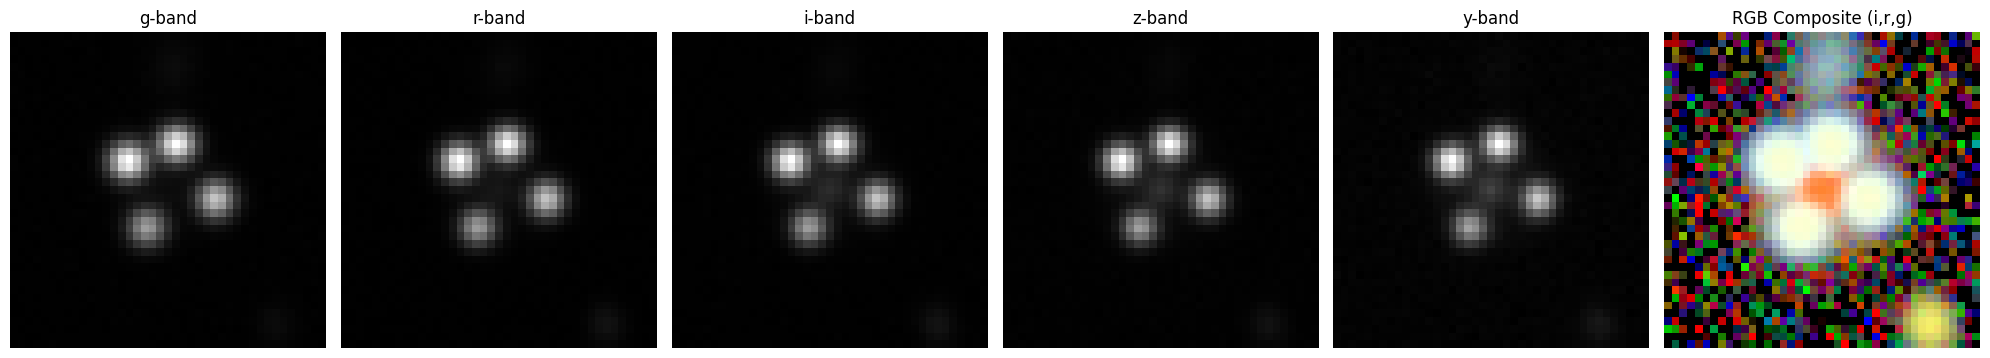

In [19]:
# load the first image in g r i z y bands to verify
test_loaded_image = {}
for band in ['g', 'r', 'i', 'z', 'y']:
    with fits.open(os.path.join(img_dir, f"{table_lensed_quasars[25060]['Lens ID']}_{band}.fits")) as hdul:
        img_data = hdul[0].data
        test_loaded_image[band] = img_data

# figure with individual band images and then an rgb composite
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for i, band in enumerate(['g', 'r', 'i', 'z', 'y']):
    axes[i].imshow(test_loaded_image[band], cmap='gray', origin='lower')
    axes[i].set_title(f"{band}-band")
    axes[i].axis('off')

# Create RGB composite
from astropy.visualization import make_lupton_rgb
rgb_image = make_lupton_rgb(test_loaded_image['i'], test_loaded_image['r'], test_loaded_image['g'], stretch=.5)

axes[5].imshow(rgb_image, origin='lower')
axes[5].set_title("RGB Composite (i,r,g)")
axes[5].axis('off')
plt.tight_layout()
plt.show()